In [1]:
import torch
print(torch.__version__)

2.2.2


In [3]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim 
from torchvision import datasets ,transforms 
from torch.utils.data import DataLoader 
import matplotlib.pyplot as plt

In [4]:
device= torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [6]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset= datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset= datasets.MNIST(root='./data', train=False, download=True, transform=transform) 
train_loader= DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader= DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:08<00:00, 1128502.80it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 102050.51it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:04<00:00, 343559.99it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 5719162.04it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Number of training samples: 60000
Number of test samples: 10000


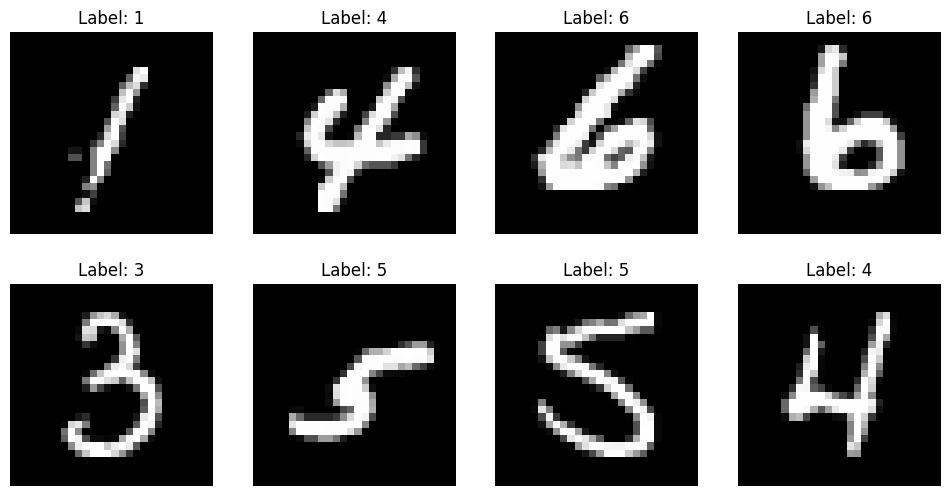

In [7]:
images , labels = next(iter(train_loader)) 
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
plt.show()


teacher is a boro model 

In [16]:
class TeacherCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        
        
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
    
teacher= TeacherCNN().to(device)
print(teacher)
        
        
        

TeacherCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [11]:
class StudentCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(16 * 14 * 14, 32)
        self.fc2 = nn.Linear(32, 10)
        
    def forward(self, x):
        x= F.relu(self.conv1(x))
        x= self.pool(x)
        x= x.view(-1, 16 * 14 * 14)
        x= F.relu(self.fc1(x))
        x= self.fc2(x)
        return x

In [12]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)    
student_top = StudentCNN().to(device)
print(student_top)
print("Teacher model parameters:", count_parameters(teacher))
print("Student model parameters:", count_parameters(student_top))

StudentCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)
Teacher model parameters: 421642
Student model parameters: 100874


In [13]:
def evaluate(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

In [17]:
def train_teacher(model, train_loader, test_loader, device, epochs=5, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        test_accuracy = evaluate(model, test_loader, device)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Test Accuracy: {test_accuracy:.2f}%")

In [18]:
teacher = TeacherCNN().to(device)
train_teacher(teacher, train_loader, test_loader, device, epochs=5)

Epoch [1/5], Loss: 0.1554, Test Accuracy: 98.60%
Epoch [2/5], Loss: 0.0456, Test Accuracy: 98.73%
Epoch [3/5], Loss: 0.0308, Test Accuracy: 98.60%
Epoch [4/5], Loss: 0.0223, Test Accuracy: 99.17%
Epoch [5/5], Loss: 0.0178, Test Accuracy: 98.98%


In [26]:
def train_student_normal(model,epochs=5): 
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        test_accuracy = evaluate(model, test_loader, device)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Test Accuracy: {test_accuracy:.2f}%")

In [20]:
student_normal= StudentCNN().to(device)
train_student_normal(student_normal, epochs=5)

Epoch [1/5], Loss: 0.3874, Test Accuracy: 95.46%
Epoch [2/5], Loss: 0.1227, Test Accuracy: 97.08%
Epoch [3/5], Loss: 0.0903, Test Accuracy: 97.23%
Epoch [4/5], Loss: 0.0727, Test Accuracy: 97.51%
Epoch [5/5], Loss: 0.0637, Test Accuracy: 97.84%


In [27]:
def train_student_kd(student,teacher,epochs=5,temperature=4.0,alpha=0.5):
    optimizer= optim.Adam(student.parameters(), lr=0.001)
    hard_criterion= nn.CrossEntropyLoss()
    teacher.eval()  
    for epoch in range(epochs):
        student.train()
        running_loss = 0.0
        for images,labels in train_loader: 
            images=images.to(device) 
            labels=labels.to(device)
            optimizer.zero_grad()
            
            with torch.no_grad():
                teacher_logits= teacher(images)
            student_logits= student(images)
            hard_loss= hard_criterion(student_logits,labels)
            teacher_probs= F.softmax(teacher_logits/temperature,dim=1)
            student_log_probs= F.log_softmax(student_logits/temperature,dim=1)
            soft_loss= F.kl_div(student_log_probs,teacher_probs,reduction='batchmean') * (temperature**2)
            loss= alpha*hard_loss + (1-alpha)*soft_loss
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

In [28]:
import inspect
expected_parameters = ('student', 'teacher', 'epochs', 'temperature', 'alpha')
if tuple(inspect.signature(train_student_kd).parameters) != expected_parameters:
    raise RuntimeError('Run the train_student_kd definition cell, then run this cell again.')

student_id = StudentCNN().to(device)
train_student_kd(student_id, teacher, epochs=5, temperature=4.0, alpha=0.5)

Epoch [1/5], Loss: 2.1564
Epoch [2/5], Loss: 0.5592
Epoch [3/5], Loss: 0.4172
Epoch [4/5], Loss: 0.3506
Epoch [5/5], Loss: 0.3138


In [30]:
teacher_acc=evaluate(teacher, test_loader, device)
normal_acc=evaluate(student_normal, test_loader, device)
kd_acc=evaluate(student_id, test_loader, device) 

print(f"Teacher model accuracy: {teacher_acc:.2f}%")
print(f"Student model (normal training) accuracy: {normal_acc:.2f}%")
print(f"Student model (knowledge distillation) accuracy: {kd_acc:.2f}%")

Teacher model accuracy: 98.98%
Student model (normal training) accuracy: 97.84%
Student model (knowledge distillation) accuracy: 98.31%


In [31]:
import matplotlib.pyplot as plt
import numpy as np 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

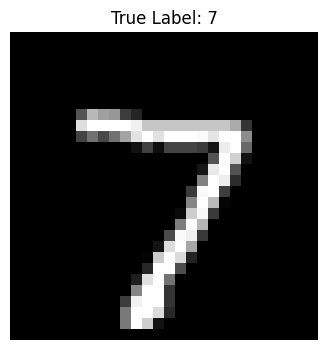

In [33]:
idx = 0 
image,label=test_dataset[idx]   
input_image=image.unsqueeze(0).to(device)
plt.figure(figsize=(4, 4))
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"True Label: {label}")
plt.axis('off')
plt.show()


In [35]:
def get_predictions(model,image): 
    model.eval()
    with torch.no_grad(): 
        logits= model(image)
        probs= F.softmax(logits,dim=1)
        pred=torch.argmax(probs,dim=1)
        confidence= probs[0][pred].item()
    return pred.item(), confidence,probs

teacher_pred, teacher_confidence, teacher_probs = get_predictions(teacher, input_image)
student_normal_pred, student_normal_confidence, student_normal_probs = get_predictions(student_normal, input_image)
student_kd_pred, student_kd_confidence, student_kd_probs = get_predictions(student_id, input_image)
print(f"Teacher model prediction: {teacher_pred}, Confidence: {teacher_confidence:.4f}")
print(f"Student model (normal training) prediction: {student_normal_pred}, Confidence: {student_normal_confidence:.4f}")
print(f"Student model (knowledge distillation) prediction: {student_kd_pred}, Confidence: {student_kd_confidence:.4f}")

Teacher model prediction: 7, Confidence: 1.0000
Student model (normal training) prediction: 7, Confidence: 1.0000
Student model (knowledge distillation) prediction: 7, Confidence: 1.0000


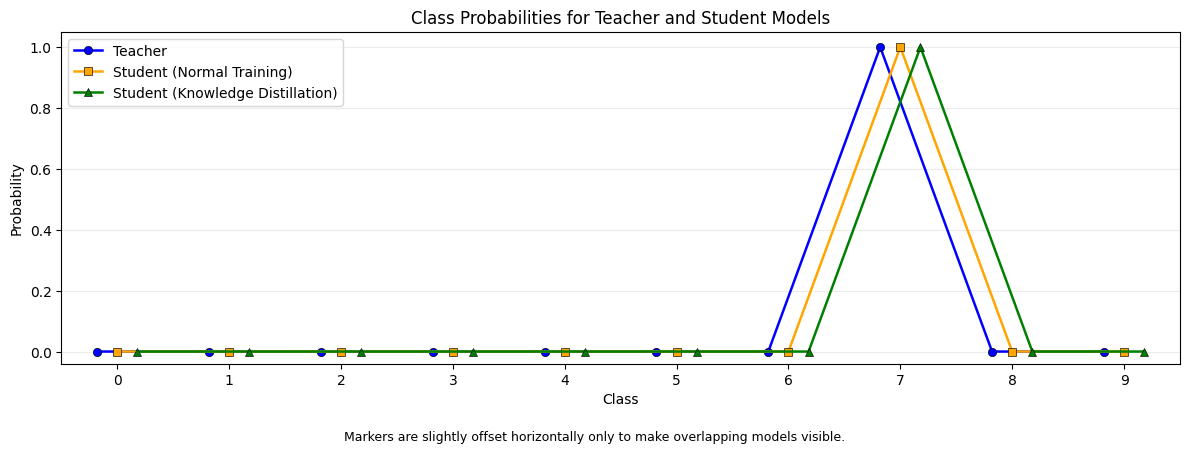

In [37]:
import numpy as np

classes = np.arange(10)
model_probabilities = [
    ('Teacher', teacher_probs.squeeze().cpu().numpy(), -0.18, 'blue', 'o'),
    ('Student (Normal Training)', student_normal_probs.squeeze().cpu().numpy(), 0.00, 'orange', 's'),
    ('Student (Knowledge Distillation)', student_kd_probs.squeeze().cpu().numpy(), 0.18, 'green', '^'),
]

fig, ax = plt.subplots(figsize=(12, 4.5))
for label, probabilities, offset, color, marker in model_probabilities:
    ax.plot(
        classes + offset, probabilities, label=label, color=color, marker=marker,
        linewidth=1.8, markersize=6, markeredgecolor='black', markeredgewidth=0.45
    )

ax.set_title('Class Probabilities for Teacher and Student Models')
ax.set_xlabel('Class')
ax.set_ylabel('Probability')
ax.set_xticks(classes)
ax.set_xlim(-0.5, 9.5)
ax.set_ylim(-0.04, 1.05)  # keeps zero-probability markers visible
ax.grid(axis='y', alpha=0.25)
ax.legend()
fig.text(0.5, 0.01, 'Markers are slightly offset horizontally only to make overlapping models visible.', ha='center', fontsize=9)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()


In [38]:
class GridCAM: 
    def __init__(self,model,target_layer): 
        self.model= model 
        self.target_layer= target_layer 
        self.gradients= None 
        self.activations= None
        self.forward_hook= self.target_layer.register_forward_hook(self.save_activation)
        self.backward_hook= self.target_layer.register_backward_hook(self.save_gradient)
        
    def save_activation(self,module,input,output):
        self.activations= output.detach()
        
    def save_gradient(self,module,grad_input,grad_output):
        self.gradients= grad_output[0].detach()
    def generate(self,image,class_idx=None): 
        self.model.eval()
        if class_idx is None: 
            class_idx = torch.argmax(self.model(image)).item() 
        self.model.zero_grad()
        score = self.model(image)[:,class_idx]
        score.backward(retain_graph=True)
        weights = torch.mean(self.gradients,dim=(2,3),keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=image.shape[2:], mode='bilinear', align_corners=False)
        cam=cam.squeeze().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() > 0 : 
            cam = cam / cam.max()
        return cam,class_idx

In [39]:
teacher.conv2

Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/nn/modules/module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


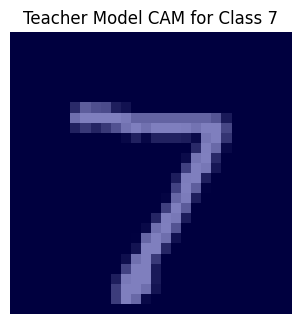

In [41]:
teacher_cam = GridCAM(teacher, teacher.conv2)
cam_teacher, class_idx_teacher = teacher_cam.generate(input_image)
teacher_cam.forward_hook.remove()
teacher_cam.backward_hook.remove()

plt.figure(figsize=(8, 4))
plt.subplot(1,2,2)
plt.imshow(image.squeeze(), cmap='gray')
plt.imshow(cam_teacher, cmap='jet', alpha=0.5)
plt.title(f"Teacher Model CAM for Class {class_idx_teacher}")
plt.axis('off')
plt.show()

In [42]:
student_normal.conv1

Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/nn/modules/module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


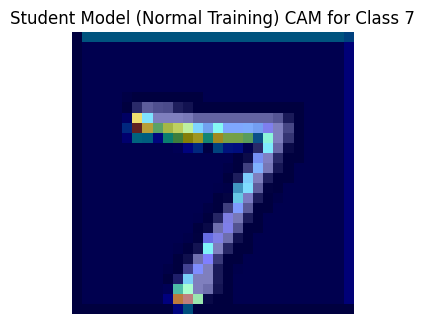

In [44]:
student_normal_cam = GridCAM(student_normal, student_normal.conv1)
cam_student_normal, class_idx_student_normal = student_normal_cam.generate(input_image)
student_normal_cam.forward_hook.remove()
student_normal_cam.backward_hook.remove()
plt.figure(figsize=(8, 4))
plt.subplot(1,2,2)
plt.imshow(image.squeeze(), cmap='gray')
plt.imshow(cam_student_normal, cmap='jet', alpha=0.5)
plt.title(f"Student Model (Normal Training) CAM for Class {class_idx_student_normal}")
plt.axis('off')
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/nn/modules/module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


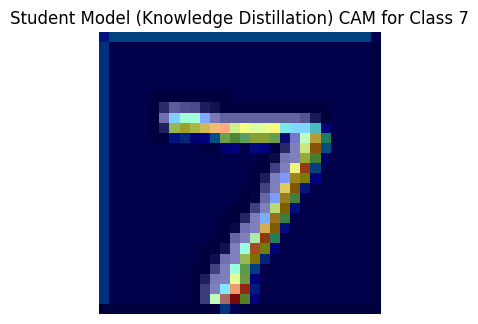

In [45]:
student_kd_cam= GridCAM(student_id, student_id.conv1)
cam_student_kd, class_idx_student_kd = student_kd_cam.generate(input_image)
student_kd_cam.forward_hook.remove()
student_kd_cam.backward_hook.remove()
plt.figure(figsize=(8, 4))
plt.subplot(1,2,2)
plt.imshow(image.squeeze(), cmap='gray')
plt.imshow(cam_student_kd, cmap='jet', alpha=0.5)
plt.title(f"Student Model (Knowledge Distillation) CAM for Class {class_idx_student_kd}")
plt.axis('off')
plt.show()


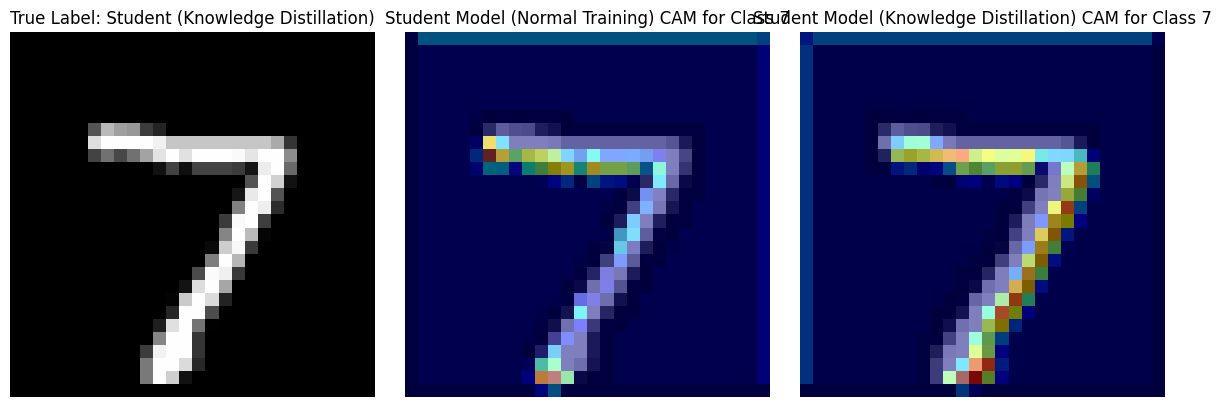

In [46]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"True Label: {label}")
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(image.squeeze(), cmap='gray')
plt.imshow(cam_student_normal, cmap='jet', alpha=0.5)
plt.title(f"Student Model (Normal Training) CAM for Class {class_idx_student_normal}")
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(image.squeeze(), cmap='gray')
plt.imshow(cam_student_kd, cmap='jet', alpha=0.5)
plt.title(f"Student Model (Knowledge Distillation) CAM for Class {class_idx_student_kd}")
plt.axis('off')
plt.tight_layout()
plt.show()

grid cam similarity 

In [48]:
normal_similarity = F.cosine_similarity(
    torch.tensor(cam_teacher).flatten(), torch.tensor(cam_student_normal).flatten(), dim=0
).item()
kd_similarity = F.cosine_similarity(
    torch.tensor(cam_teacher).flatten(), torch.tensor(cam_student_kd).flatten(), dim=0
).item()
print(f"Cosine similarity between Teacher and Student (Normal Training) CAMs: {normal_similarity:.4f}")
print(f"Cosine similarity between Teacher and Student (Knowledge Distillation) CAMs: {kd_similarity:.4f}")

Cosine similarity between Teacher and Student (Normal Training) CAMs: 0.0000
Cosine similarity between Teacher and Student (Knowledge Distillation) CAMs: 0.0000
